In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from sklearn.feature_extraction.text import CountVectorizer
from category_encoders import BinaryEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from keras.utils import to_categorical
from sklearn.metrics import classification_report
from keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from keras.callbacks import EarlyStopping
from keras.regularizers import l2
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV


In [2]:
data = pd.read_csv('Stars.csv')
data.head()

,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068,0.002400,0.1700,16.12,Red,M,0
1,3042,0.000500,0.1542,16.60,Red,M,0
2,2600,0.000300,0.1020,18.70,Red,M,0
3,2800,0.000200,0.1600,16.65,Red,M,0
4,1939,0.000138,0.1030,20.06,Red,M,0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    str    
 5   Spectral_Class  240 non-null    str    
 6   Type            240 non-null    int64  
dtypes: float64(3), int64(2), str(2)
memory usage: 13.3 KB


In [4]:
numeric_cols = data.select_dtypes(include = ['int64','float64']).columns
numeric_cols

Index(['Temperature', 'L', 'R', 'A_M', 'Type'], dtype='str')

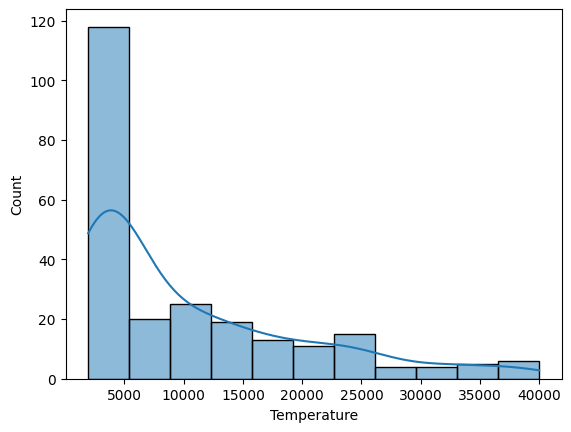

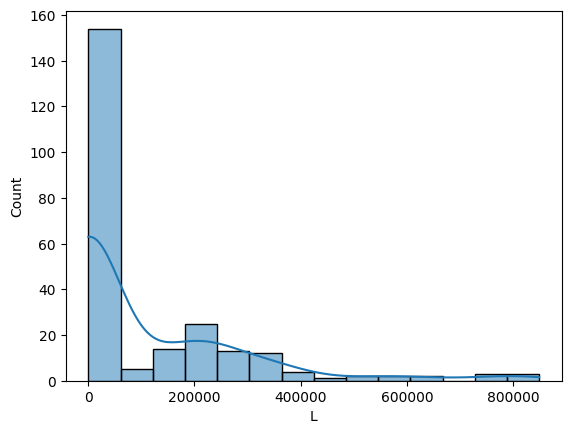

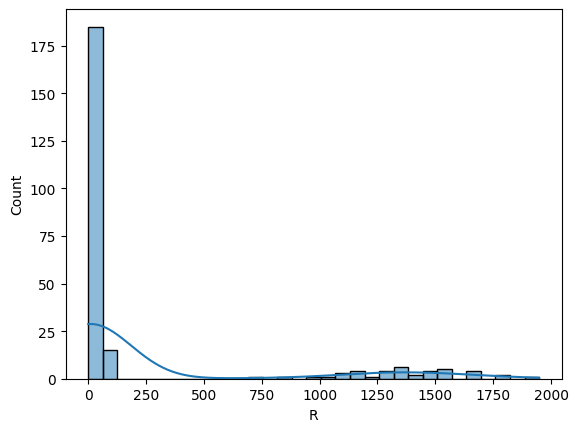

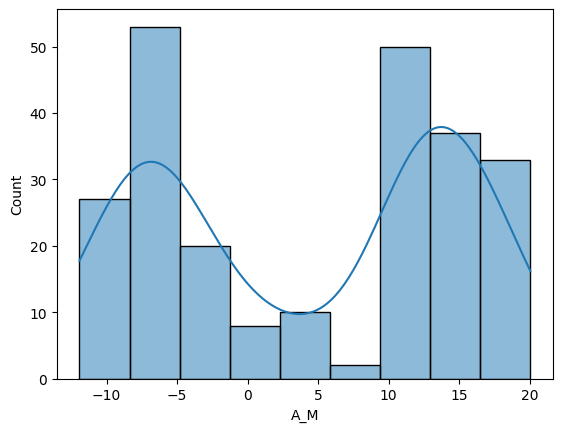

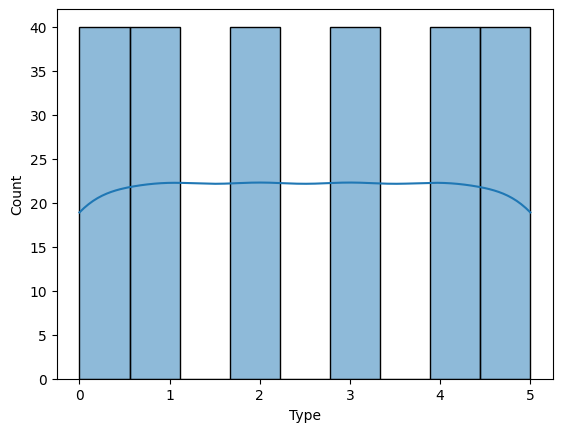

In [5]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(data[col], kde = True)
    plt.show()

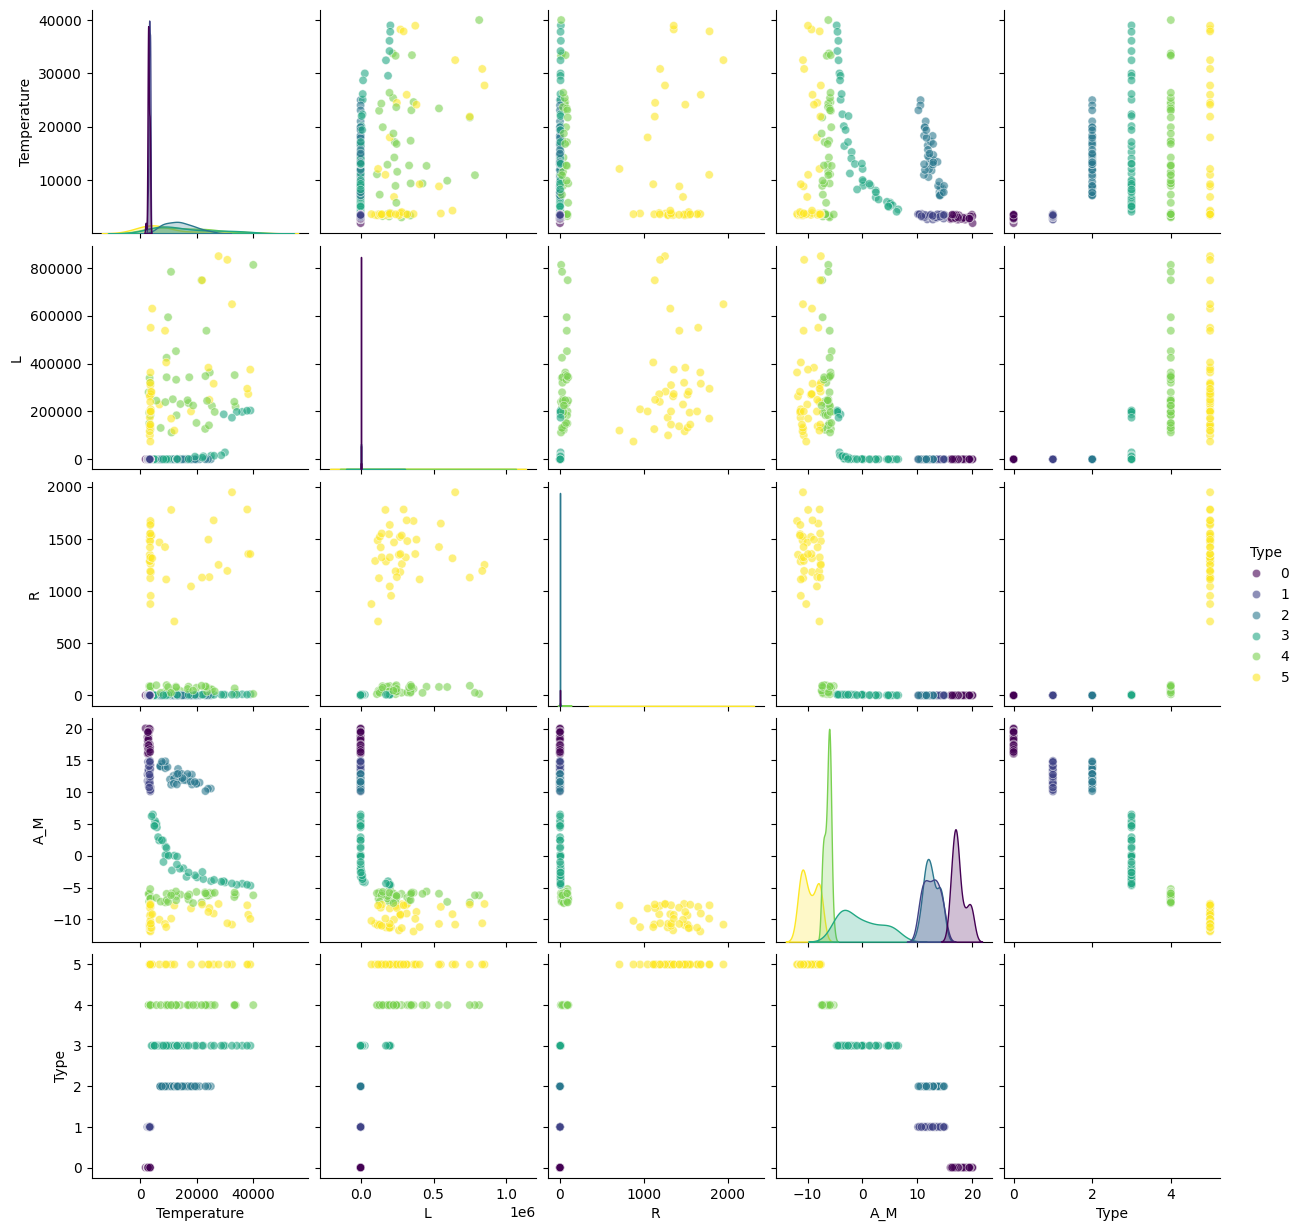

In [6]:
sns.pairplot(
    data, 
    hue='Type', 
    vars=['Temperature', 'L', 'R', 'A_M', 'Type'],
    palette='viridis',
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)

plt.show()

In [7]:
data['Color'].value_counts()

Color
Red                   112
Blue                   56
Blue-white             26
Blue White             10
yellow-white            8
White                   7
Blue white              4
Yellowish White         3
white                   3
Whitish                 2
Orange                  2
yellowish               2
Pale yellow orange      1
White-Yellow            1
Yellowish               1
Orange-Red              1
Blue-White              1
Name: count, dtype: int64

In [8]:
len(data['Color'].value_counts())

17

In [9]:
data['Spectral_Class'].value_counts()

Spectral_Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64

In [10]:
len(data['Spectral_Class'].value_counts())

7

In [11]:
data['Type'].value_counts()

Type
0    40
1    40
2    40
3    40
4    40
5    40
Name: count, dtype: int64

In [12]:
encoder = BinaryEncoder(cols=['Spectral_Class'])
data_encoded = encoder.fit_transform(data)

In [13]:
data_encoded.head()

,Temperature,L,R,A_M,Color,Spectral_Class_0,Spectral_Class_1,Spectral_Class_2,Type
0,3068,0.002400,0.1700,16.12,Red,0,0,1,0
1,3042,0.000500,0.1542,16.60,Red,0,0,1,0
2,2600,0.000300,0.1020,18.70,Red,0,0,1,0
3,2800,0.000200,0.1600,16.65,Red,0,0,1,0
4,1939,0.000138,0.1030,20.06,Red,0,0,1,0


In [14]:
encoder = TargetEncoder(cols=['Color'])
data_encoded[['Color']] = encoder.fit_transform(data_encoded[['Color']], data['Temperature'])

In [15]:
data_encoded.head()

,Temperature,L,R,A_M,Color,Spectral_Class_0,Spectral_Class_1,Spectral_Class_2,Type
0,3068,0.002400,0.1700,16.12,3292.513698,0,0,1,0
1,3042,0.000500,0.1542,16.60,3292.513698,0,0,1,0
2,2600,0.000300,0.1020,18.70,3292.513698,0,0,1,0
3,2800,0.000200,0.1600,16.65,3292.513698,0,0,1,0
4,1939,0.000138,0.1030,20.06,3292.513698,0,0,1,0


In [16]:
X = data_encoded.drop(columns = 'Type')
y = data_encoded['Type']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [18]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (192, 8)
X_test shape: (48, 8)
y_train shape: (192,)
y_test shape: (48,)


In [19]:
robust_cols = ['Temperature', 'L', 'R']
standard_cols = ['A_M','Color']

preprocessor = ColumnTransformer(
    transformers=[
        ('robust', RobustScaler(), robust_cols),
        ('std', StandardScaler(), standard_cols)
    ],
    remainder='passthrough' 
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [20]:
y_train = to_categorical(y_train, num_classes=6)

In [21]:
y_test = to_categorical(y_test, num_classes=6)

In [22]:
model = Sequential()

In [23]:
model.add(Dense(64, activation='relu', input_shape=(8,), kernel_regularizer=l2(0.001)))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.2))

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2\env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.add(Dense(6, activation='softmax'))

In [25]:
custom_learning_rate = 0.001
optimizer = Adam(learning_rate=custom_learning_rate)

In [26]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [27]:
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy','Precision','Recall']
)

In [28]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - Precision: 0.0417 - Recall: 0.0065 - accuracy: 0.1569 - loss: 3.7015 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_accuracy: 0.1282 - val_loss: 2.9694
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - Precision: 0.0000e+00 - Recall: 0.0000e+00 - accuracy: 0.2222 - loss: 3.0829 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_accuracy: 0.2051 - val_loss: 2.5218
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - Precision: 0.0000e+00 - Recall: 0.0000e+00 - accuracy: 0.2092 - loss: 2.7104 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_accuracy: 0.3077 - val_loss: 2.1664
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - Precision: 0.0000e+00 - Recall: 0.0000e+00 - accuracy: 0.2288 - loss: 2.4007 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_accuracy: 0.3846 - val_loss: 1.9312
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - Precision: 0.0000e+00 - Recall: 0.0000e+00 - accuracy: 0.261

In [29]:
train_predictions = model.predict(X_train_scaled)
test_predictions = model.predict(X_test_scaled)

train_pred_classes = np.argmax(train_predictions, axis=1)
test_pred_classes = np.argmax(test_predictions, axis=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [30]:
y_train_classes = np.argmax(y_train, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

In [31]:
print(classification_report(y_train_classes, train_pred_classes))
print(classification_report(y_test_classes, test_pred_classes))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        32
           1       1.00      0.94      0.97        33
           2       1.00      1.00      1.00        34
           3       0.94      1.00      0.97        32
           4       1.00      0.94      0.97        32
           5       1.00      1.00      1.00        29

    accuracy                           0.98       192
   macro avg       0.98      0.98      0.98       192
weighted avg       0.98      0.98      0.98       192

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00        11

    accuracy                           1.00        48
   macro avg       1.00

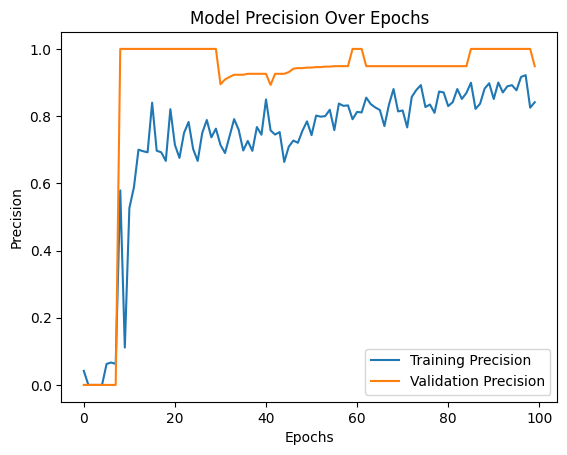

In [32]:
plt.plot(history.history['Precision'], label='Training Precision')
plt.plot(history.history['val_Precision'], label='Validation Precision')

plt.title('Model Precision Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.show()

Hyperparameter tuning

In [ ]:
def build_model(learning_rate=0.001, dropout_rate=0.3, l2_reg=0.001, 
                units_layer1=64, units_layer2=32, units_layer3=16):
    
    model = Sequential()
    model.add(Input(shape=(X_train_scaled.shape[1],)))
    
    model.add(Dense(units_layer1, activation='relu', kernel_regularizer=l2(l2_reg)))
    model.add(Dropout(dropout_rate))
    
    model.add(Dense(units_layer2, activation='relu', kernel_regularizer=l2(l2_reg)))
    model.add(Dropout(dropout_rate))
    
    model.add(Dense(units_layer3, activation='relu', kernel_regularizer=l2(l2_reg)))
    model.add(Dropout(dropout_rate))
    
    model.add(Dense(6, activation='softmax'))
    
    optimizer = Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [36]:
keras_clf = KerasClassifier(
    model=build_model,
    learning_rate=0.001,
    dropout_rate=0.3,
    l2_reg=0.001,
    units_layer1=64,
    units_layer2=32,
    units_layer3=16,
    epochs=100,
    batch_size=32,
    verbose=0
)

In [37]:
param_dist = {
    'learning_rate': [0.0005, 0.001, 0.005],
    'dropout_rate': [0.2, 0.3, 0.4, 0.5],          
    'l2_reg': [0.001, 0.005, 0.01, 0.05],          
    'units_layer1': [32, 64, 128],                 
    'units_layer2': [16, 32, 64],
    'units_layer3': [8, 16, 32],
    'batch_size': [16, 32, 64]
}

In [38]:
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

In [39]:
random_search = RandomizedSearchCV(
    estimator=keras_clf,
    param_distributions=param_dist,
    n_iter=15,           
    cv=3,                
    scoring='accuracy',
    random_state=42,
    n_jobs=1            
)

In [40]:
search_result = random_search.fit(
    X_train_scaled, 
    y_train, 
    callbacks=[early_stop], 
    validation_split=0.2
)

In [41]:
print(f"Best Accuracy: {search_result.best_score_:.4f}")
print(f"Best Parameters: {search_result.best_params_}")

Best Accuracy: 0.9792
Best Parameters: {'units_layer3': 32, 'units_layer2': 32, 'units_layer1': 128, 'learning_rate': 0.005, 'l2_reg': 0.005, 'dropout_rate': 0.5, 'batch_size': 16}


In [59]:
model = Sequential()

In [60]:
model.add(Dense(64, activation='relu', input_shape=(8,), kernel_regularizer=l2(0.005)))
model.add(Dropout(0.5))

model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.005)))
model.add(Dropout(0.5))

model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.005)))
model.add(Dropout(0.5))

model.add(Dense(6, activation='softmax'))

custom_learning_rate = 0.005
optimizer = Adam(learning_rate=custom_learning_rate)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy','Precision','Recall']
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop]
)

train_predictions = model.predict(X_train_scaled)
test_predictions = model.predict(X_test_scaled)

train_pred_classes = np.argmax(train_predictions, axis=1)
test_pred_classes = np.argmax(test_predictions, axis=1)

y_train_classes = np.argmax(y_train, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

Epoch 1/100


c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2\env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - Precision: 0.1429 - Recall: 0.0196 - accuracy: 0.1176 - loss: 3.2545 - val_Precision: 1.0000 - val_Recall: 0.1795 - val_accuracy: 0.4103 - val_loss: 1.8733
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - Precision: 0.5238 - Recall: 0.0719 - accuracy: 0.2484 - loss: 2.4136 - val_Precision: 1.0000 - val_Recall: 0.1795 - val_accuracy: 0.4103 - val_loss: 1.7368
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - Precision: 0.7000 - Recall: 0.0915 - accuracy: 0.3072 - loss: 1.9729 - val_Precision: 1.0000 - val_Recall: 0.1795 - val_accuracy: 0.5897 - val_loss: 1.6628
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - Precision: 0.8095 - Recall: 0.1111 - accuracy: 0.2941 - loss: 1.8559 - val_Precision: 1.0000 - val_Recall: 0.1795 - val_accuracy: 0.6410 - val_loss: 1.5970
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - Precision: 0.7826 - Recall: 0.1176 - accuracy: 0.3529 - loss: 1.7613 - val_Precision: 1.0000 - val_Recall: 0.1795 - va

In [ ]:
print(classification_report(y_train_classes, train_pred_classes))
print(classification_report(y_test_classes, test_pred_classes))